# Aprendizaxe Supervisada

Tomaremos como referencia el dataset credit_train.csv y credit_test.csv que contienen la información sobre una campaña de márketing llevada a cabo mediante llamadas teléfonicas para captar clientes que quieran acceder a un crédito.

**Features o Input variables:**

1 - age: edad numérica

2 - job : tipo de trabajo (puede tomar los valores: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')

3 - marital : estado civil (puede tomar los valores: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)

4 - education : nivel de estudios (puede tomar los valores: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')

5 - default: ya tiene un crédito solicitado por defecto? (puede tomar los valores: 'no','yes','unknown')

6 - housing: tiene hipoteca? (puede tomar los valores: 'no','yes','unknown')

7 - loan: tiene una cuenta personal? (puede tomar los valores: 'no','yes','unknown')

8 - contact: tipo de comunicación de contacto (puede tomar los valores: 'cellular','telephone')

9 - month: último mes de contacto (puede tomar los valores: 'jan', 'feb', 'mar', ..., 'nov', 'dec')

10 - day_of_week: último día de la semana en el que se le ha contactado (puede tomar los valores: 'mon','tue','wed','thu','fri')

11 - duration: duración del último contacto en segundos (numérico). Importante: este atributo afecta en gran medida a la salida ya que si duration es 0, entonces  la salida es 'no'

12 - campaign: número de veces que se le ha contactado durante la campaña a este cliente (numérico, incluye el último contacto)

13 - pdays: número de días que han pasado desde que el cliente fue contactado por última vez(numérico; 999 significa que no ha sido contactado anteriormente)

14 - previous: número de contactos anteriores a esta campaña a este cliente(numérico)

15 - poutcome: resultado de la última campaña de marketing (categorical: 'failure','nonexistent','success')

16 - emp.var.rate: employment variation rate - quarterly indicator (numérico)

17 - cons.price.idx: IPC - indicador mensual (numérico)

18 - cons.conf.idx: índice de confianza de los consumidores - indicador mensual (numérico)

19 - euribor3m: euribor tasa 3 meses - indicador diario (numérico)

20 - nr.employed: número de trabajadores - indicador en porciones  (numérico)

**Output variable (desired target):**

21 - y: Suscripción al crédito por parte del cliente? (binary: 'yes','no')

#### 1. K-Nearest Neighbors (KNN)

K-Nearest Neighbors es un algoritmo de clasificación (también puede usarse para regresión, pero no es lo habitual). No construye un modelo como tal, sino que utiliza directamente los datos de entrenamiento.

- **Funcionamiento**: para clasificar un nuevo dato, compara ese dato con los ya conocidos, busca los *k* más parecidos y asigna la clase más frecuente entre ellos.
- **Distancia**: normalmente se usa la distancia euclidiana cuando las variables son numéricas.
- **Valor de k**: si *k* es pequeño, el modelo es sensible al ruido; si es grande, pierde precisión y aumenta el coste de cálculo.

---

#### 2. Regresión Lineal (Simple y Múltiple)

La Regresión Lineal se utiliza para predecir valores numéricos a partir de una o varias variables de entrada.

- **Objetivo**: encontrar una relación lineal entre las variables que minimice el error entre los valores reales y los predichos.
- **Salida**: genera valores continuos, por lo que no es adecuada para problemas donde la respuesta es *sí / no*, como en este proyecto.

---

#### 3. Regresión Logística

La Regresión Logística es un modelo diseñado específicamente para problemas de clasificación binaria.

- **Salida**: devuelve una probabilidad entre 0 y 1 que indica la posibilidad de que ocurra el evento (por ejemplo, que un cliente contrate el producto).
- **Clasificación**: esa probabilidad se convierte en una decisión final (*sí* o *no*) aplicando un umbral.
- **Ventaja clave**: es sencilla, rápida y fácil de interpretar.

---

#### 4. Árboles de Decisión y Random Forest

- **Árboles de Decisión**: dividen los datos en función de reglas simples basadas en las variables, hasta llegar a una decisión final.
- **Random Forest**: combina muchos árboles de decisión y une sus resultados para obtener una predicción más fiable.
- **Ventaja principal**: reduce el riesgo de sobreajuste y funciona bien incluso con datos poco limpios.

---

#### 5. Support Vector Machines (SVM)

Support Vector Machine es un algoritmo de aprendizaje supervisado usado principalmente en clasificación.

- **Funcionamiento**: busca separar los datos en grupos de la forma más clara posible.
- **Datos complejos**: puede manejar relaciones no lineales entre variables sin necesidad de transformaciones manuales.
- **Fortaleza**: suele ofrecer muy buen rendimiento en problemas de clasificación exigentes.

---

### Modelos Óptimos Seleccionados para el Proyecto

Dado que la variable objetivo (`y`: *yes / no*) corresponde a un problema de **clasificación binaria**, la Regresión Lineal se descarta.

Los tres modelos más adecuados para este proyecto son:

| Modelo               | Motivo de la elección |
|----------------------|-----------------------|
| Regresión Logística  | Modelo base en clasificación binaria. Es eficiente, interpretable y permite trabajar con probabilidades. |
| Random Forest        | Modelo robusto y estable, con buen rendimiento y menor riesgo de sobreajuste. |
| Support Vector Machine (SVM) | Clasificador potente que suele ofrecer buenos resultados incluso en escenarios complejos. |


## 1. Importación de paquetes y dataset

Importación del dataset

In [1]:
# Importing Data Analysis Librarys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
plt.rcParams['figure.figsize'] = (16, 9)
plt.style.use('ggplot')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from math import sqrt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree, DecisionTreeClassifier, export_graphviz
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_curve, auc
from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
warnings.filterwarnings('ignore')

In [2]:
credit = pd.read_csv("credit-train.csv")

credit_test = pd.read_csv("credit-test.csv")

## 2.EDA y Visual EDA

In [3]:
credit.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1


Comprobamos si existen valores nulos (missing values) que requieran tratamiento y verificamos los tipos de datos de cada columna.

In [4]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

In [5]:
credit.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'],
      dtype='object')

In [6]:
credit.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp_var_rate      0
cons_price_idx    0
cons_conf_idx     0
euribor3m         0
nr_employed       0
y                 0
dtype: int64

In [7]:
credit_test.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp_var_rate      0
cons_price_idx    0
cons_conf_idx     0
euribor3m         0
nr_employed       0
dtype: int64

Ni en el train ni en el test hay valores nulos

In [8]:
credit.duplicated().sum()

np.int64(12)

In [9]:
credit_test.duplicated().sum()

np.int64(0)

En el train hay 12 valores duplicados
En el test hay valores duplicados

Analizamos la distribución de las variables numéricas y las relaciones entre ellas para detectar patrones o anomalías (outliers).

#### 2.1 Conocer las variables categóricas

Se examinan las categorías de las variables cualitativas para identificar su cardinalidad y evaluar el método de codificación más adecuado en fases posteriores.

In [10]:
print('Trabajos:\n', credit['job'].unique())

Trabajos:
 ['blue-collar' 'technician' 'management' 'services' 'retired' 'admin.'
 'housemaid' 'unemployed' 'entrepreneur' 'self-employed' 'unknown'
 'student']


In [11]:
print('Marital:\n', credit['marital'].unique())

Marital:
 ['married' 'single' 'divorced' 'unknown']


In [12]:
print('Education:\n', credit['education'].unique())

Education:
 ['basic.4y' 'unknown' 'university.degree' 'high.school' 'basic.9y'
 'professional.course' 'basic.6y' 'illiterate']


In [13]:
print('Default:\n', credit['default'].unique())
print('Housing:\n', credit['housing'].unique())
print('Loan:\n', credit['loan'].unique())

Default:
 ['unknown' 'no' 'yes']
Housing:
 ['yes' 'no' 'unknown']
Loan:
 ['no' 'yes' 'unknown']


#### 2.2 Conocer las variables numericas
Se estudia la distribución de las variables numéricas para detectar asimetrías, valores extremos y posibles transformaciones necesarias antes del modelado.

In [14]:
print('Min edad: ', credit['age'].max())
print('Max edad: ', credit['age'].min())
print('Valores Nulos: ', credit['age'].isnull().any())

Min edad:  98
Max edad:  17
Valores Nulos:  False


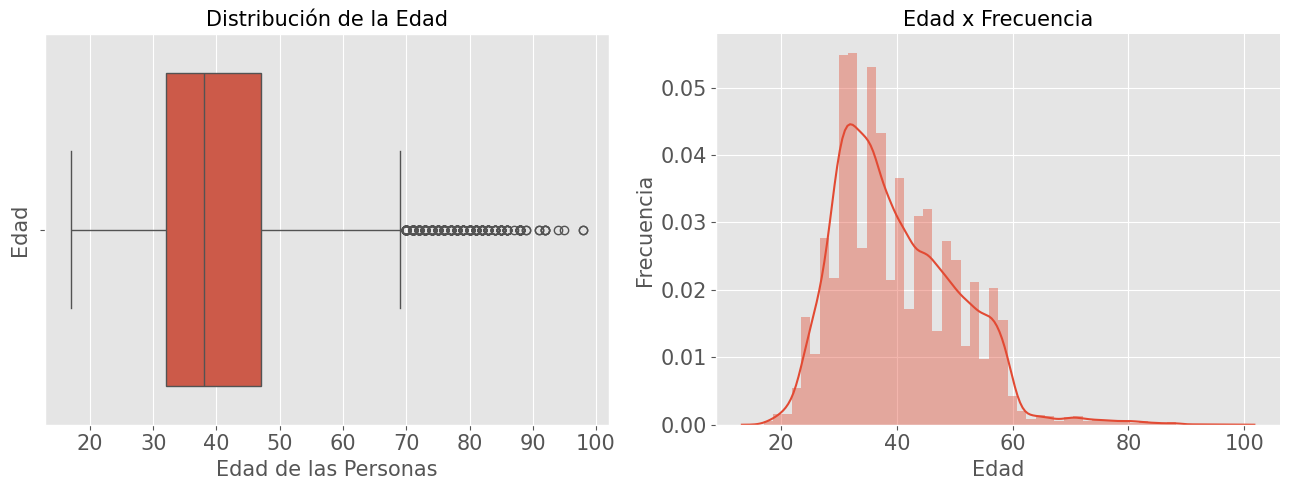

In [15]:
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (13, 5))

# Gráfico 1: Diagrama de Caja (Boxplot)
sns.boxplot(x = 'age', data = credit, orient = 'v', ax = ax1)
ax1.set_xlabel('Edad de las Personas', fontsize=15)
ax1.set_ylabel('Edad', fontsize=15)
ax1.set_title('Distribución de la Edad', fontsize=15)
ax1.tick_params(labelsize=15)

# Gráfico 2: Histograma de distribución
sns.distplot(credit['age'], ax = ax2)
sns.despine(ax = ax2)
ax2.set_xlabel('Edad', fontsize=15)
ax2.set_ylabel('Frecuencia', fontsize=15)
ax2.set_title('Edad x Frecuencia', fontsize=15)
ax2.tick_params(labelsize=15)

plt.subplots_adjust(wspace=0.5)
plt.tight_layout()

Se analiza la distribución de la edad para detectar posibles valores atípicos y comprobar si existe una relación evidente con la variable objetivo. La distribución es asimétrica, con mayor concentración en edades medias, y no se observan valores extremos que justifiquen su eliminación. A simple vista no se aprecia una relación fuerte con la variable objetivo, por lo que será el modelo el encargado de capturar posibles efectos no lineales.


In [16]:
# Cuartiles
print('1º Cuartil: ', credit['age'].quantile(q = 0.25))
print('2º Cuartil: ', credit['age'].quantile(q = 0.50))
print('3º Cuartil: ', credit['age'].quantile(q = 0.75))
print('4º Cuartil: ', credit['age'].quantile(q = 1.00))

print('Edades por encima de: ', credit['age'].quantile(q = 0.75) + 
                      1.5*(credit['age'].quantile(q = 0.75) - credit['age'].quantile(q = 0.25)), 'son outliers')

1º Cuartil:  32.0
2º Cuartil:  38.0
3º Cuartil:  47.0
4º Cuartil:  98.0
Edades por encima de:  69.5 son outliers


In [17]:
print('Numero de outliers: ', credit[credit['age'] > 69.6]['age'].count())
print('Numbero de clientes: ', len(credit))
#Outliers in %
print('Porcentaje de outliers:', round(credit[credit['age'] > 69.6]['age'].count()*100/len(credit),2), '%')

Numero de outliers:  469
Numbero de clientes:  41188
Porcentaje de outliers: 1.14 %


In [18]:
print('MEDIA:', round(credit['age'].mean(), 1))

print('DESV :', round(credit['age'].std(), 1))

print('CV   :',round(credit['age'].std()*100/credit['age'].mean(), 1), ', Dispersión media alta')

MEDIA: 40.0
DESV : 10.4
CV   : 26.0 , Dispersión media alta


#### 2.3 JOBS

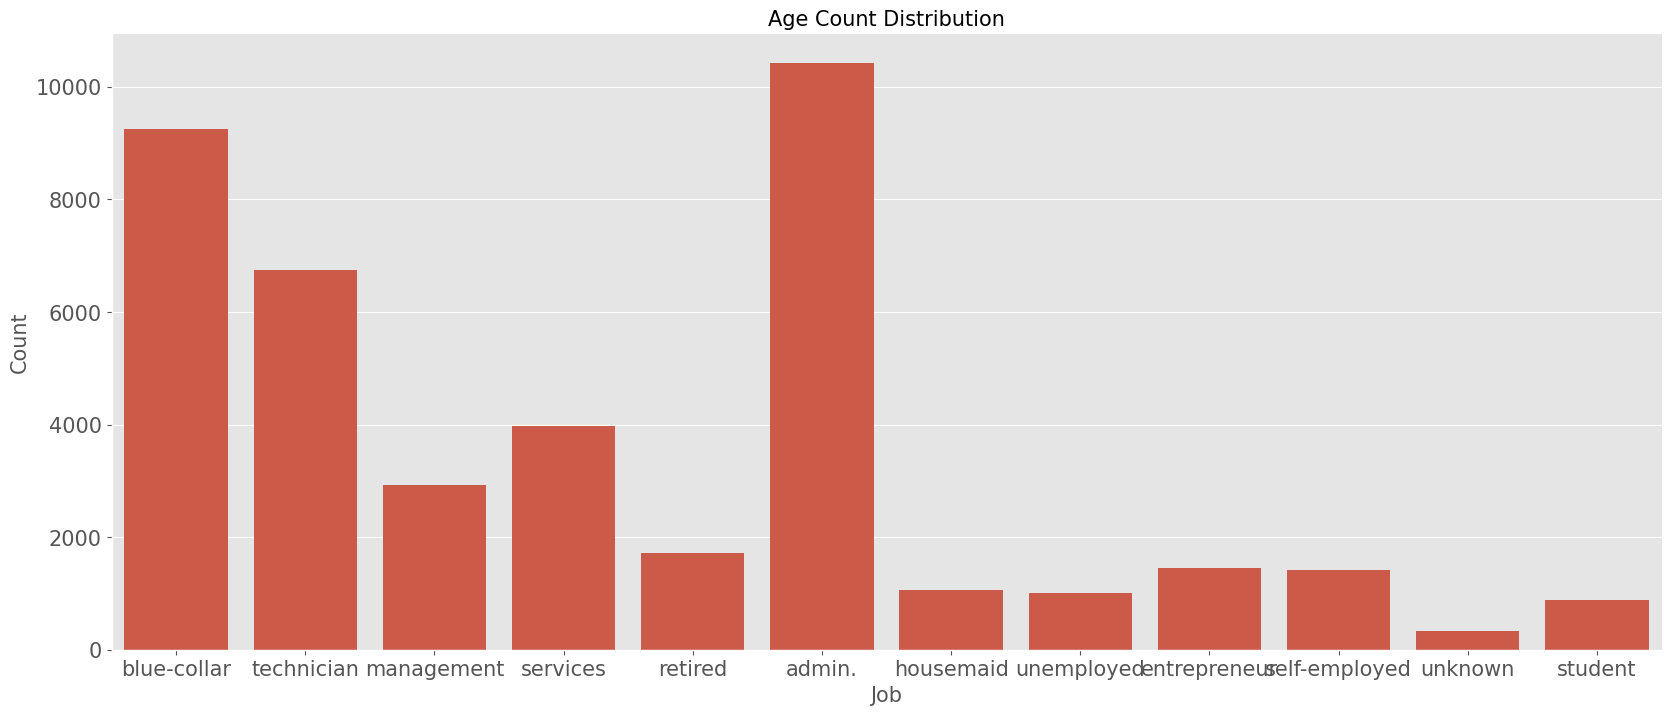

In [19]:
# Qué tipo de trabajos tienen los clientes de este banco;
fig, ax = plt.subplots()
fig.set_size_inches(20, 8)
sns.countplot(x = 'job', data = credit)
ax.set_xlabel('Job', fontsize=15)
ax.set_ylabel('Count', fontsize=15)
ax.set_title('Age Count Distribution', fontsize=15)
ax.tick_params(labelsize=15)
sns.despine()

Se estudia la relación entre el tipo de trabajo y la variable objetivo para identificar posibles segmentos con mayor tasa de conversión. Se observan diferencias claras entre categorías, lo que indica que esta variable contiene información relevante para el modelo y justifica su inclusión tras un proceso adecuado de codificación.

#### 2.4 MARITAL

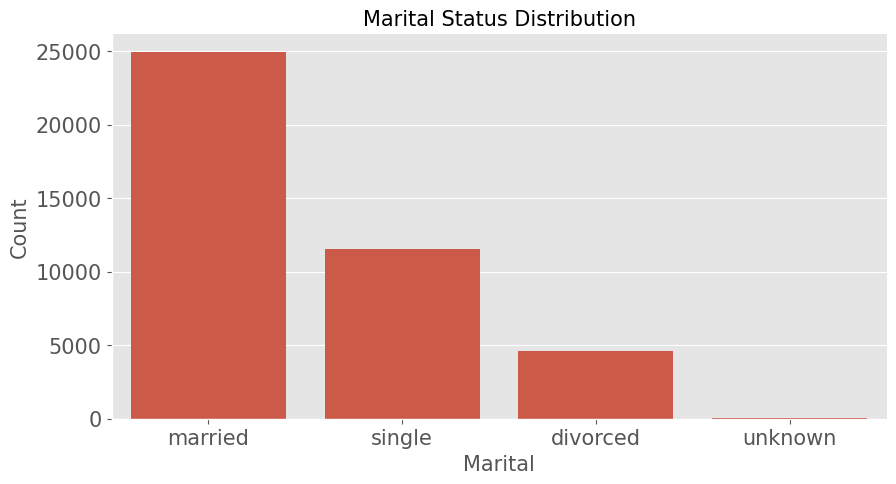

In [20]:
fig, ax = plt.subplots()
fig.set_size_inches(10, 5)
sns.countplot(x = 'marital', data = credit)
ax.set_xlabel('Marital', fontsize=15)
ax.set_ylabel('Count', fontsize=15)
ax.set_title('Marital Status Distribution', fontsize=15)
ax.tick_params(labelsize=15)
sns.despine()

La gran mayoría son casados (aprox. 25,000), superando por más del doble a los solteros. Esto suele indicar clientes con mayor estabilidad, pero también con más cargas familiares.

#### 2.5 EDUCATION¶

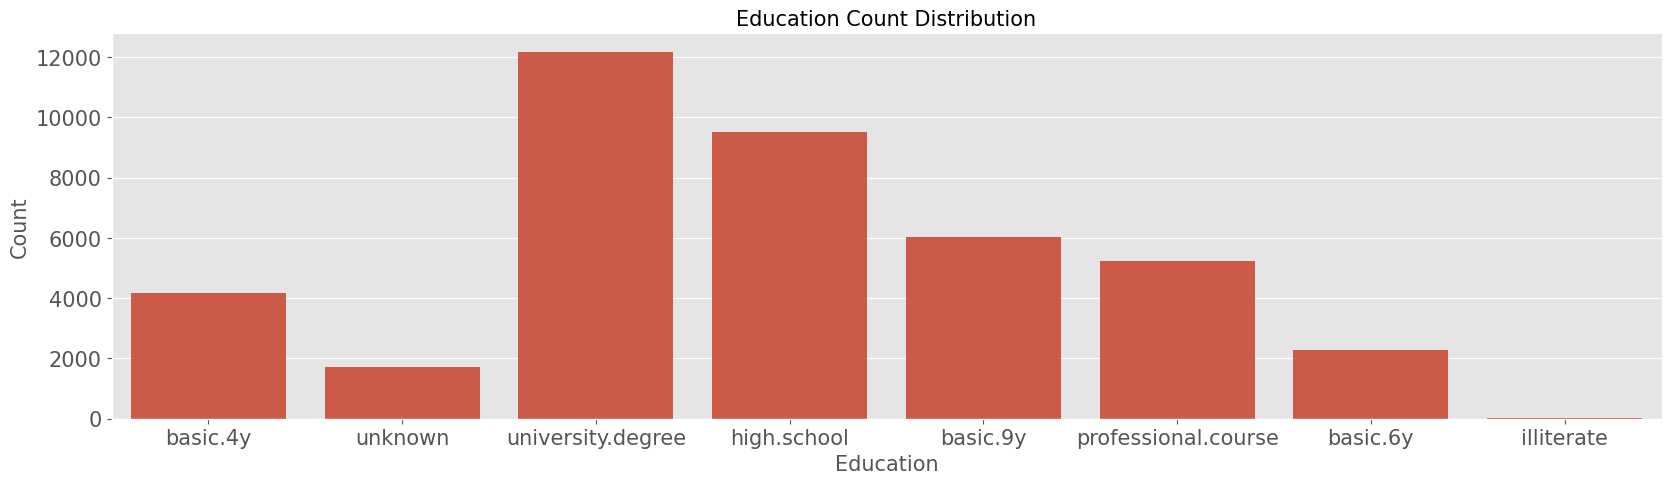

In [21]:
fig, ax = plt.subplots()
fig.set_size_inches(20, 5)
sns.countplot(x = 'education', data = credit)
ax.set_xlabel('Education', fontsize=15)
ax.set_ylabel('Count', fontsize=15)
ax.set_title('Education Count Distribution', fontsize=15)
ax.tick_params(labelsize=15)
sns.despine()

El dataset tiene un sesgo claro hacia la educación superior. La categoría university.degree es la más frecuente, seguida de high.school.
Combinado con el gráfico anterior (mayoría casados), esto refuerza la idea de un perfil de cliente de clase media/estable.

#### 2.6. DEFAULT, HOUSING, LOAN

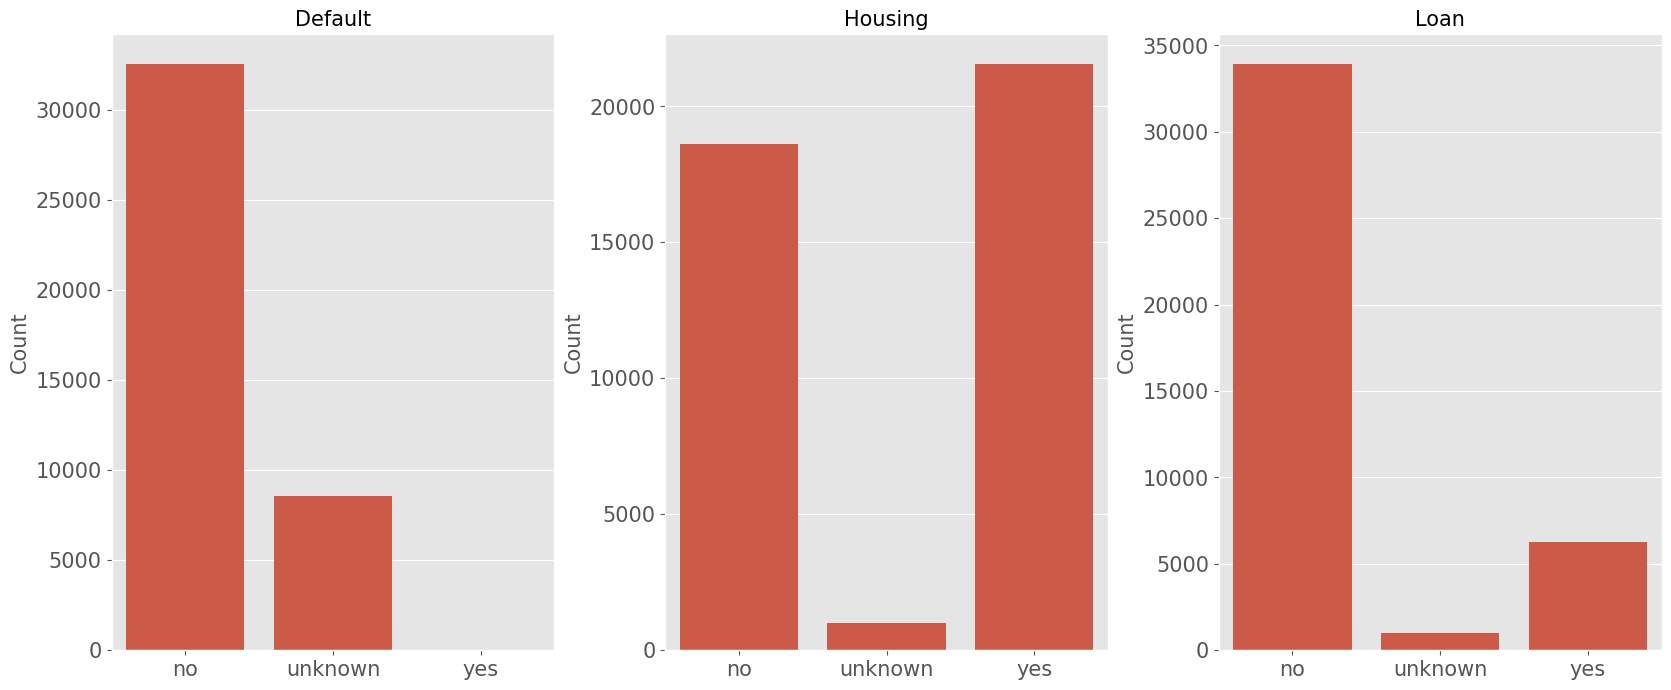

In [22]:
# Default: tiene crédito en incumplimiento?
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(20,8))
sns.countplot(x='default', data=credit, ax=ax1, order=['no', 'unknown', 'yes'])
ax1.set_title('Default', fontsize=15)
ax1.set_xlabel('')
ax1.set_ylabel('Count', fontsize=15)
ax1.tick_params(labelsize=15)

# Housing: tiene préstamo hipotecario?
sns.countplot(x='housing', data=credit, ax=ax2, order=['no', 'unknown', 'yes'])
ax2.set_title('Housing', fontsize=15)
ax2.set_xlabel('')
ax2.set_ylabel('Count', fontsize=15)
ax2.tick_params(labelsize=15)

# Loan: tiene préstamo personal?
sns.countplot(x='loan', data=credit, ax=ax3, order=['no', 'unknown', 'yes'])
ax3.set_title('Loan', fontsize=15)
ax3.set_xlabel('')
ax3.set_ylabel('Count', fontsize=15)
ax3.tick_params(labelsize=15)

plt.subplots_adjust(wspace=0.25)


Bloque Default (Incumplimiento): La barra no es enorme, la barra unknown es significativa (unas 8,500) y la barra yes es invisible (casi cero). El modelo no tendrá suficientes ejemplos de "gente que no paga" (yes) para aprender, y hay demasiados datos desconocidos (unknown) que ensucian esta variable.

Bloque Housing (Hipoteca): Las barras de no y yes tienen alturas comparables, siendo yes (con hipoteca) ligeramente superior (más de 20,000). Muestra que la población está dividida casi a la mitad, lo cual es excelente para que el modelo encuentre patrones claros.

Bloque Loan (Préstamo Personal): La barra no es dominante (cerca de 34,000) frente a una barra yes pequeña (aprox 6,000). La gran mayoría de los clientes no tiene préstamos personales activos. Esto confirma un perfil de cliente conservador o que no suele endeudarse por consumo.

#### 2.7 CONTACT, MONTH, DAY_OF_WEEK

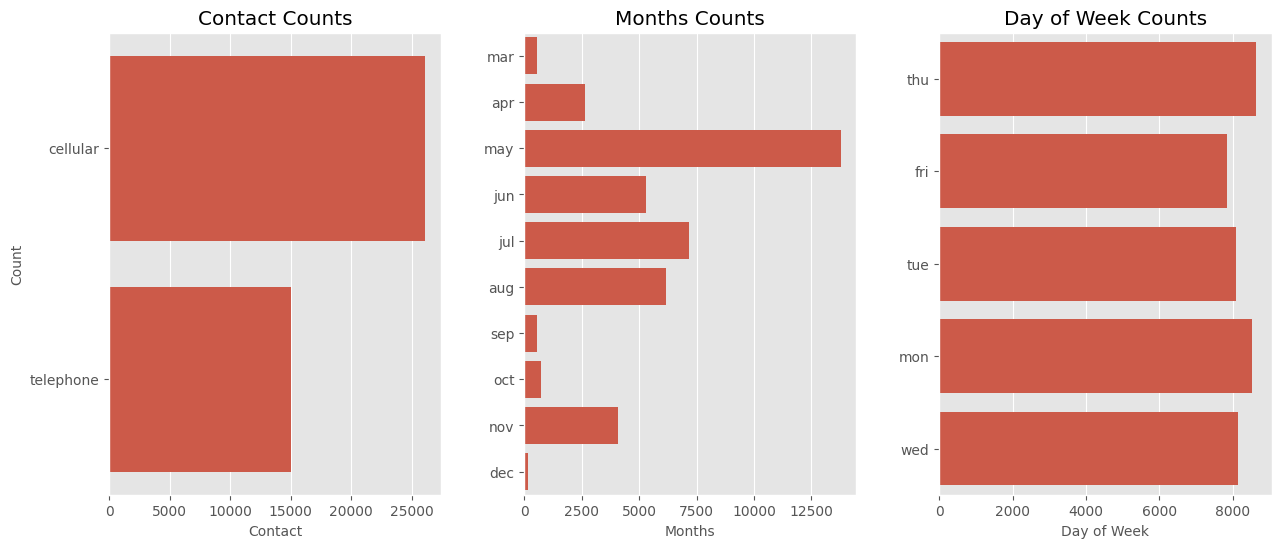

In [23]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows = 1, ncols = 3, figsize = (15,6))
sns.countplot(credit['contact'], ax = ax1)
ax1.set_xlabel('Contact', fontsize = 10)
ax1.set_ylabel('Count', fontsize = 10)
ax1.set_title('Contact Counts')
ax1.tick_params(labelsize=10)

sns.countplot(credit['month'], ax = ax2, order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'])
ax2.set_xlabel('Months', fontsize = 10)
ax2.set_ylabel('')
ax2.set_title('Months Counts')
ax2.tick_params(labelsize=10)

sns.countplot(credit['day_of_week'], ax = ax3)
ax3.set_xlabel('Day of Week', fontsize = 10)
ax3.set_ylabel('')
ax3.set_title('Day of Week Counts')
ax3.tick_params(labelsize=10)

plt.subplots_adjust(wspace=0.25)

Bloque Contacto (Contact): La barra de cellular (móvil) es casi el doble de larga que la de telephone (fijo), con unos 26,000 registros frente a 15,000. La estrategia de contacto es moderna o prioriza los móviles. Al modelar, el tipo de dispositivo podría influir en si la persona contesta o no (la tasa de respuesta suele variar entre fijo y móvil).

Bloque Meses (Months - Estacionalidad): Hay un pico gigante en Mayo (may), que supera por mucho a cualquier otro mes. Los meses de verano (jul, aug, jun) tienen actividad media, mientras que dec, sep, oct y mar son casi nulos. Los datos tienen un sesgo temporal extremo. No es una muestra aleatoria de todo el año; refleja probablemente una campaña masiva específica que ocurrió en mayo.

Bloque Día de la Semana (Day of Week): Todas las barras (mon a fri) son casi idénticas en longitud (alrededor de 8,000 cada una). Es probable que esta variable tenga poco poder predictivo

#### 2.8 VARIABLES INDIVIDUALES 

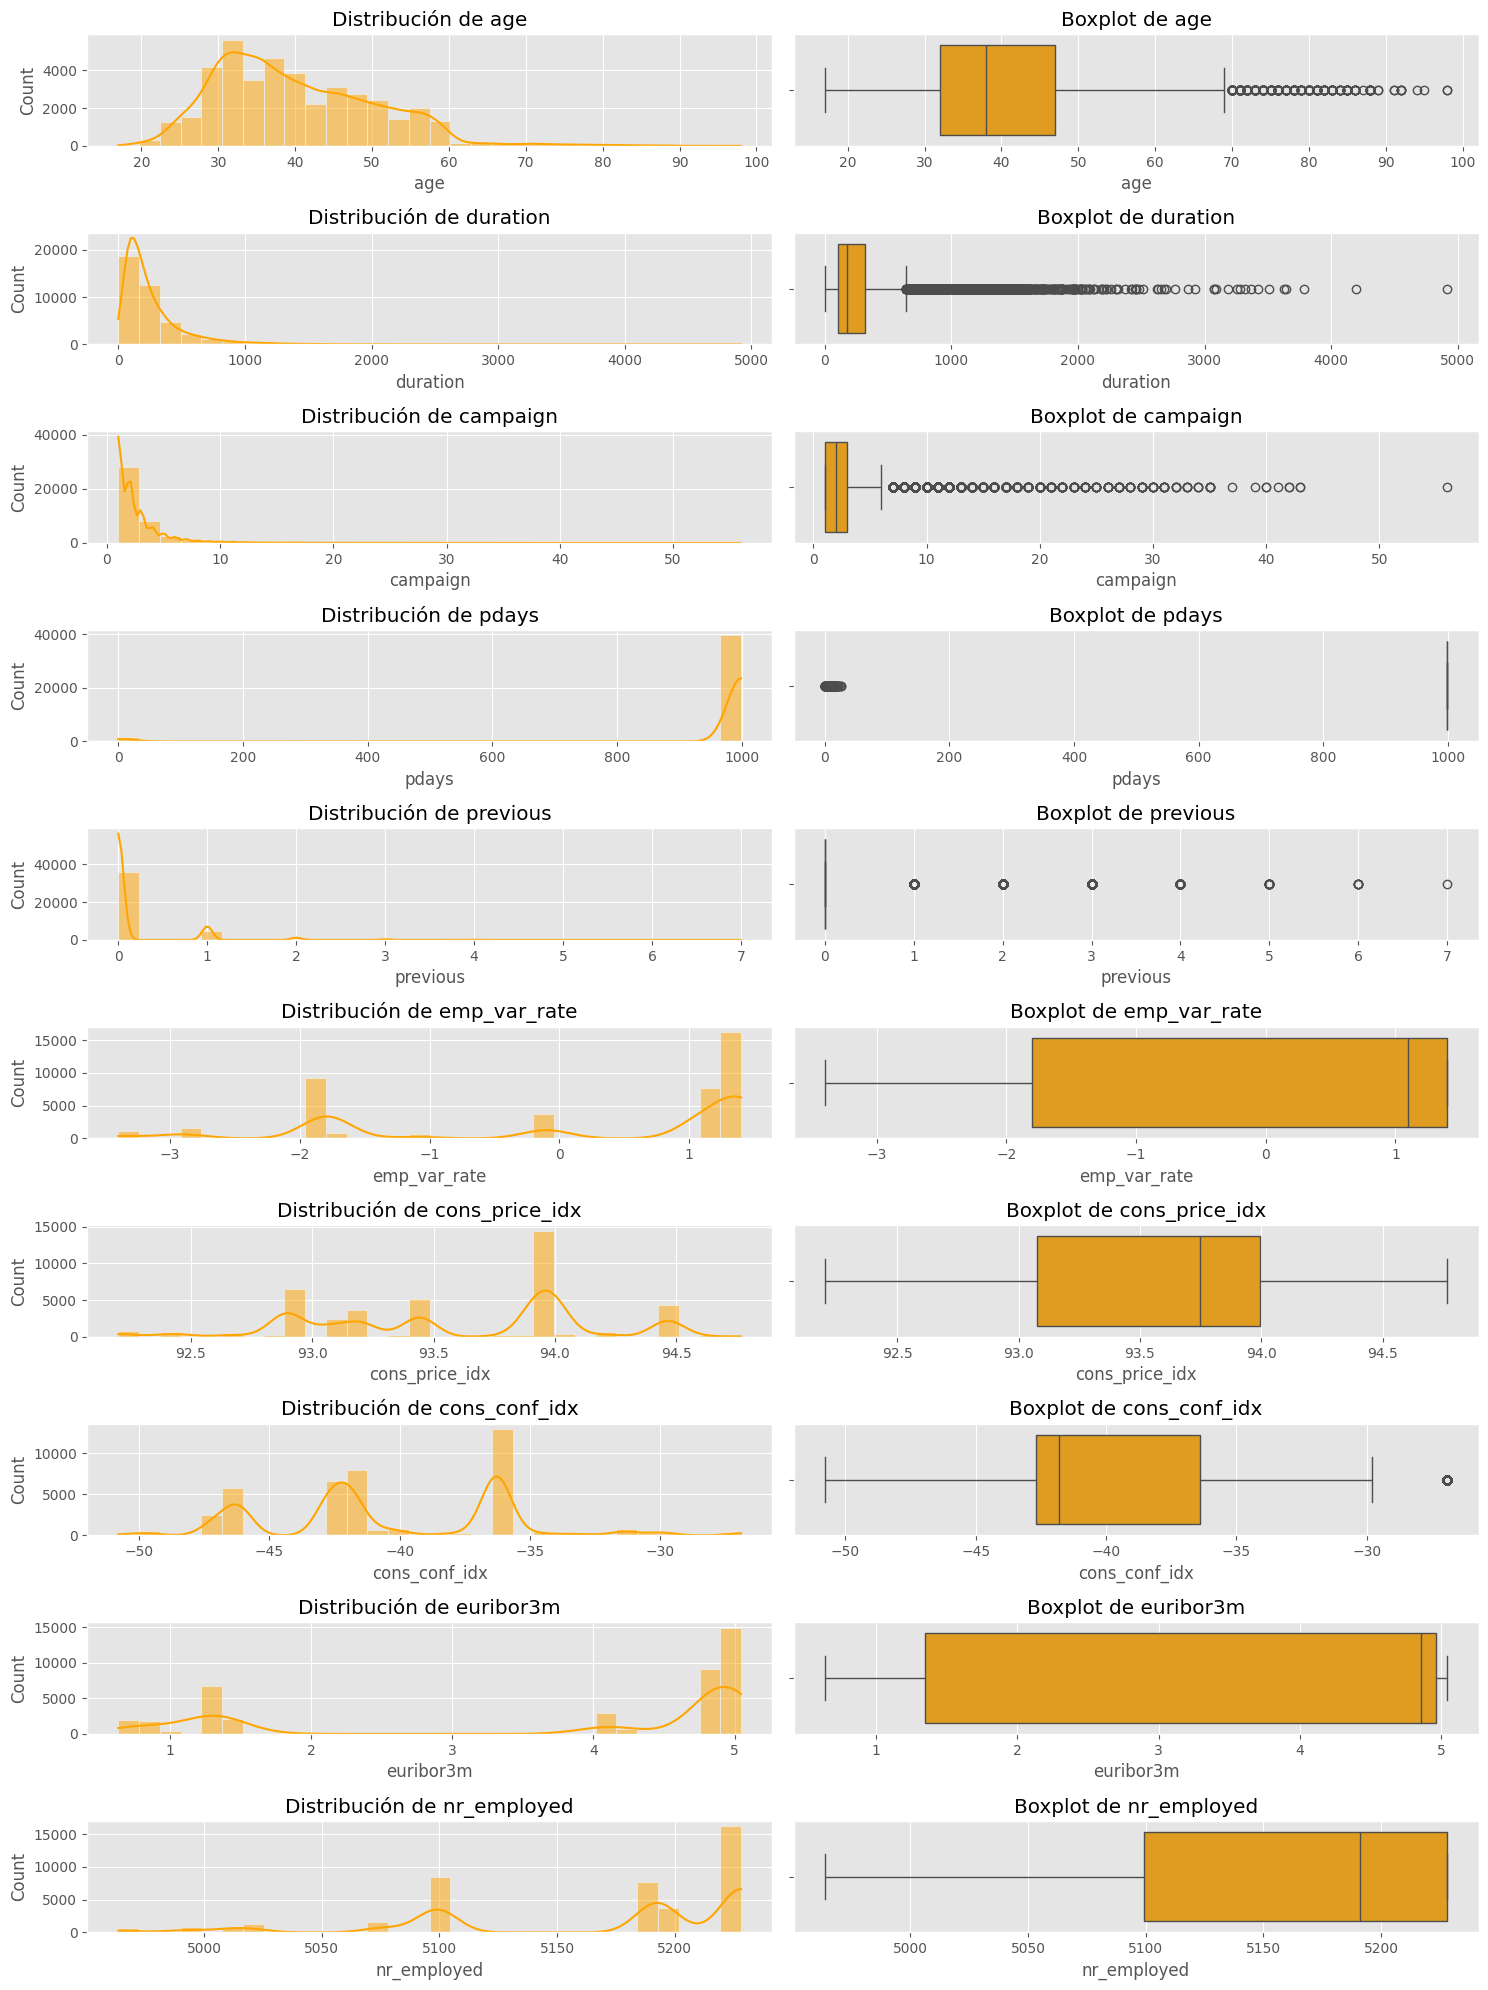

In [24]:
# Definimos las columnas numéricas (excluyendo la target)
num_cols = ['age', 'duration', 'campaign', 'pdays', 'previous', 
            'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed']

# Configuración de gráficos
plt.figure(figsize=(15, 20))

for i, col in enumerate(num_cols):
    # Histograma
    plt.subplot(len(num_cols), 2, 2*i + 1)
    sns.histplot(credit[col], kde=True, bins=30, color='orange')
    plt.title(f'Distribución de {col}')
    
    # Boxplot (para ver outliers)
    plt.subplot(len(num_cols), 2, 2*i + 2)
    sns.boxplot(x=credit[col], color='orange')
    plt.title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

1. Perfil de Edad (age) Observo que la gran mayoría de los clientes se concentra en el rango de los 30 a 40 años, que constituye mi población económicamente más activa. El boxplot revela una cantidad significativa de outliers por encima de los 70 años, esto sugiere que los jubilados son casos atípicos en la muestra y podrían comportarse de manera muy distinta al resto.

2. Contacto Previo (pdays) El histograma de pdays es muy revelador: casi la totalidad de los datos se agrupan en el valor 999.999 significa que no ha sido contactado anteriormente

3. Indicadores Económicos (euribor3m, nr_employed, emp_var_rate) Al analizar las variables macroeconómicas, no veo curvas suaves, sino distribuciones con picos muy marcados y separados. Esto indica que los datos no fueron recolectados de manera uniforme a lo largo del tiempo, sino que reflejan momentos muy específicos de la situación económica (probablemente campañas puntuales).

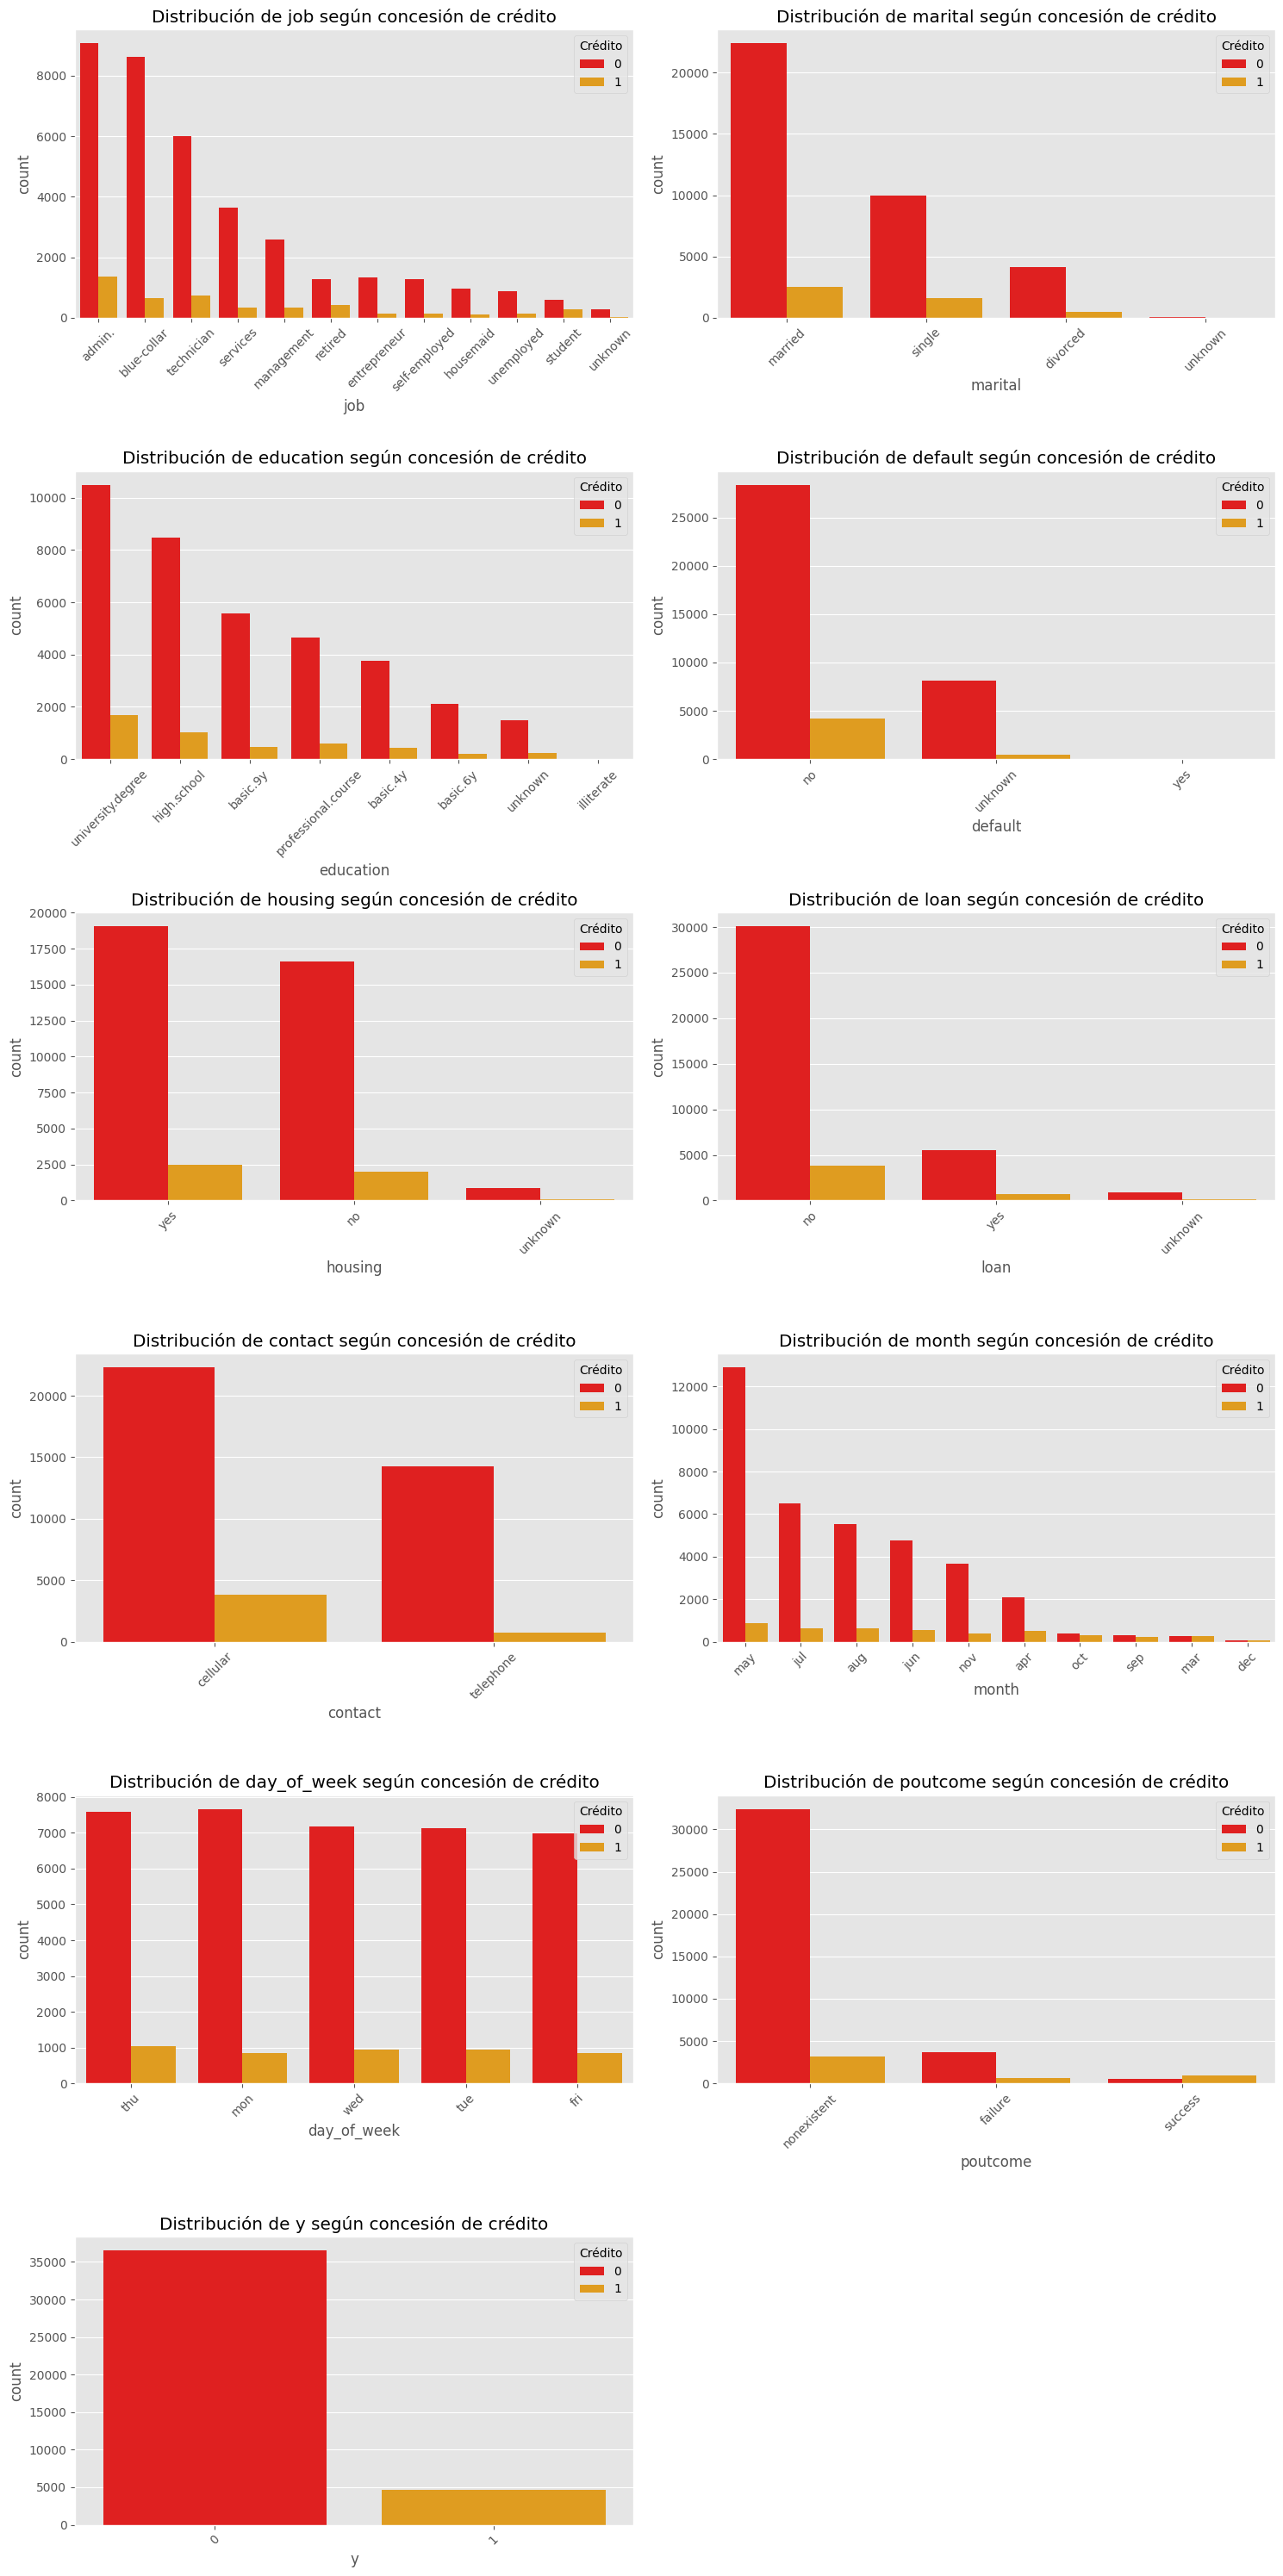

In [25]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 
            'contact', 'month', 'day_of_week', 'poutcome', 'y']

plt.figure(figsize=(15, 30))

for i, col in enumerate(cat_cols):
    plt.subplot(6, 2, i + 1)
    col_order = credit[col].value_counts().index
    sns.countplot(
        data=credit,
        x=col,
        hue='y',
        order=col_order,
        palette=['red', 'orange']
    )
    plt.title(f'Distribución de {col} según concesión de crédito')
    plt.xticks(rotation=45)
    plt.legend(title='Crédito')

plt.tight_layout()
plt.show()

Perfil del Cliente: Predomina un perfil conservador y estable: personas casadas, con trabajo administrativo y educación superior.

Calidad de Variables: La variable default es prácticamente inútil porque casi no tiene variación (casi nadie tiene impagos), mientras que housing (hipoteca) es la más equilibrada y útil para separar grupos.

Sesgo Temporal: Hay un problema de estacionalidad: la mayoría de los datos son de mayo, lo que sesga la muestra. Por el contrario, el día de la semana es irrelevante (distribución plana).

Target Desbalanceado: La variable objetivo y tiene muchísimos más "no" que "sí". Esto confirma que tendré que usar técnicas de balanceo o métricas específicas (como Recall) en lugar de solo mirar la exactitud (Accuracy).

#### 2.9 Relaciones entre variables

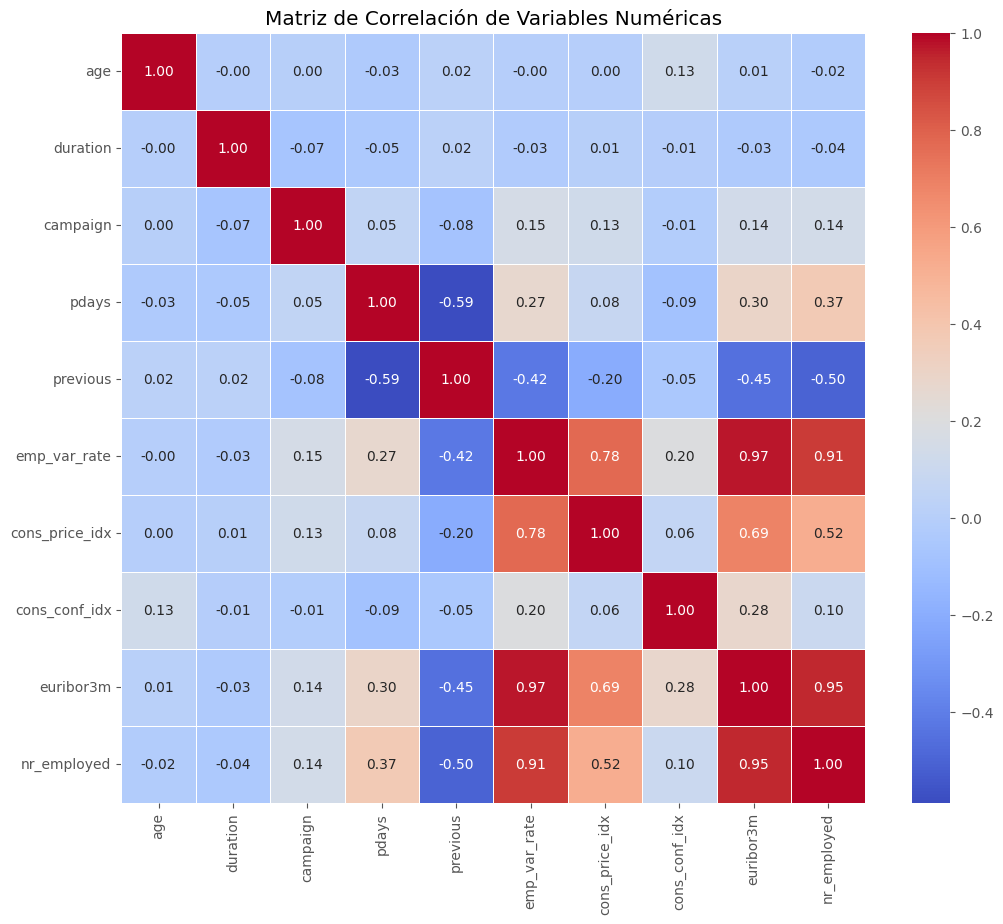

In [26]:
# Calculamos la correlación solo de las columnas numéricas
plt.figure(figsize=(12, 10))
corr_matrix = credit[num_cols].corr()

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

Alerta de Multicolinealidad (Bloque Rojo Inferior): He notado que las variables económicas (emp_var_rate, euribor3m y nr_employed) están extremadamente correlacionadas entre sí (valores de 0.95 a 0.97).

Relación Histórica (pdays vs previous): Existe una correlación negativa fuerte (-0.59) entre estas dos. Es lógico: si ya hubo contactos previos (previous), la variable de días (pdays) deja de ser 999. Esto confirma que ambas miden la "temperatura" de la relación con el cliente.

Independencia de la Edad y Duración: Me llama la atención que age y duration tienen colores muy claros (correlación casi 0) con el resto. Son variables muy "independientes", lo cual es bueno porque aportan información única que no se solapa con los datos económicos.

In [27]:
print('Impago de crédito:'
      '\n No tiene impago:'          , credit[credit['default'] == 'no']     ['age'].count(),
      '\n Impago desconocido:'       , credit[credit['default'] == 'unknown']['age'].count(),
      '\n Sí tiene impago:'          , credit[credit['default'] == 'yes']    ['age'].count())


Impago de crédito:
 No tiene impago: 32588 
 Impago desconocido: 8597 
 Sí tiene impago: 3


In [28]:
print('Préstamo hipotecario:'
      '\n No tiene préstamo:'           , credit[credit['housing'] == 'no']['age'].count(),
      '\n Préstamo desconocido:'        , credit[credit['housing'] == 'unknown']['age'].count(),
      '\n Sí tiene préstamo:'           , credit[credit['housing'] == 'yes']['age'].count())


Préstamo hipotecario:
 No tiene préstamo: 18622 
 Préstamo desconocido: 990 
 Sí tiene préstamo: 21576


In [29]:
print('Préstamo personal:'
      '\n No tiene préstamo:'     , credit[credit['loan'] == 'no']['age'].count(),
      '\n Préstamo desconocido:'        , credit[credit['loan'] == 'unknown']['age'].count(),
      '\n Sí tiene préstamo:'           , credit[credit['loan'] == 'yes']['age'].count())


Préstamo personal:
 No tiene préstamo: 33950 
 Préstamo desconocido: 990 
 Sí tiene préstamo: 6248


## 3. Preprocessing data


In [30]:
credit.drop_duplicates(inplace=True)

#### 3.1 Tratamiento d elas variables categoricas

In [31]:
# Education tiene un orden lógico, lo convertimos manualmente
education_mapping = {
    'illiterate': 1,
    'basic.4y': 2,
    'basic.6y': 3,
    'basic.9y': 4,
    'high.school': 5,
    'professional.course': 6,
    'university.degree': 7,
    'unknown': 8
}
#--------------------------Preparacion train-------------------------
credit['education'] = credit['education'].map(education_mapping)
#--------------------------Preparacion test--------------------------
credit_test['education'] = credit_test['education'].map(education_mapping)

In [32]:
for df in [credit, credit_test]:
    df['was_contacted'] = df['pdays'].apply(lambda x: 0 if x == 999 else 1)
    
    df.drop('pdays', axis=1, inplace=True)

In [33]:
labelencoder_X = LabelEncoder()
#--------------------------Preparacion train-------------------------
credit['was_contacted']= labelencoder_X.fit_transform(credit['was_contacted'])
credit['job']          = labelencoder_X.fit_transform(credit['job']) 
credit['marital']      = labelencoder_X.fit_transform(credit['marital']) 
credit['education']    = labelencoder_X.fit_transform(credit['education']) 
credit['housing']      = labelencoder_X.fit_transform(credit['housing']) 
credit['loan']         = labelencoder_X.fit_transform(credit['loan']) 
credit['poutcome']     = labelencoder_X.fit_transform(credit['poutcome']) 

#--------------------------Preparacion test--------------------------
credit_test['was_contacted']= labelencoder_X.fit_transform(credit_test['was_contacted'])
credit_test['job']          = labelencoder_X.fit_transform(credit_test['job']) 
credit_test['marital']      = labelencoder_X.fit_transform(credit_test['marital']) 
credit_test['education']    = labelencoder_X.fit_transform(credit_test['education']) 
credit_test['housing']      = labelencoder_X.fit_transform(credit_test['housing']) 
credit_test['loan']         = labelencoder_X.fit_transform(credit_test['loan']) 
credit_test['poutcome']     = labelencoder_X.fit_transform(credit_test['poutcome']) 

In [34]:
credit_cat = credit.iloc[:, list(range(0,7)) + [14]]

In [35]:
print(credit.shape)
credit_cat.head()

(41176, 21)


,age,job,marital,education,default,housing,loan,emp_var_rate
0,44,1,1,1,unknown,2,0,1.4
1,53,9,1,7,no,0,0,-0.1
2,28,4,2,6,no,2,0,-1.7
3,39,7,1,4,no,0,0,-1.8
4,55,5,1,1,no,2,0,-2.9


#### 3.2 Relacionado con el último contacto de la campaña actual

In [36]:
from sklearn.preprocessing import LabelEncoder

labelencoder_X = LabelEncoder()
#--------------------------Preparacion train--------------------------
credit['contact']     = labelencoder_X.fit_transform(credit['contact'])
credit['month']       = labelencoder_X.fit_transform(credit['month'])

#--------------------------Preparacion test--------------------------
credit_test['contact']     = labelencoder_X.fit_transform(credit_test['contact'])
credit_test['month']       = labelencoder_X.fit_transform(credit_test['month'])

In [37]:
credit_temp = credit.iloc[: , 7:11]
credit_temp.head()

,contact,month,day_of_week,duration
0,0,1,thu,210
1,0,7,fri,138
2,0,4,thu,339
3,0,0,fri,185
4,0,1,fri,137


In [38]:
credit.isnull().any()

age               False
job               False
marital           False
education         False
default           False
housing           False
loan              False
contact           False
month             False
day_of_week       False
duration          False
campaign          False
previous          False
poutcome          False
emp_var_rate      False
cons_price_idx    False
cons_conf_idx     False
euribor3m         False
nr_employed       False
y                 False
was_contacted     False
dtype: bool

In [39]:
credit_test.isnull().any()

age               False
job               False
marital           False
education         False
default           False
housing           False
loan              False
contact           False
month             False
day_of_week       False
duration          False
campaign          False
previous          False
poutcome          False
emp_var_rate      False
cons_price_idx    False
cons_conf_idx     False
euribor3m         False
nr_employed       False
was_contacted     False
dtype: bool

In [40]:
print("Tipo de contacto: \n", credit['contact'].unique())
print("\nEn qué meses se realizó esta campaña: \n", credit['month'].unique())
print("\nQué días de la semana se realizó esta campaña: \n", credit['day_of_week'].unique())

Tipo de contacto: 
 [0 1]

En qué meses se realizó esta campaña: 
 [1 7 4 0 3 6 8 5 9 2]

Qué días de la semana se realizó esta campaña: 
 ['thu' 'fri' 'tue' 'mon' 'wed']


#### 3.3 Borrar variables

In [41]:
cols_to_drop = [
    'duration',       
    'default',        
    'nr_employed',   
    'emp_var_rate', 
    'day_of_week'
]

# Eliminamos las columnas del train
credit = credit.drop(columns=cols_to_drop, axis=1)

# Eliminamos las columnas del test
credit_test = credit_test.drop(columns=cols_to_drop, axis=1)

Las varibles se eliminarion por los siguientes motivos:
    
    - duration                   = este atributo afecta en gran medida a la salida ya que si duration es 0, entonces la salida es 'no'
    - default                    = En este dataset específico, la gran mayoría de los registros tienen el valor "no" o "unknown".
    - nr_employed y emp_var_rate = Estas variables suelen estar altamente correlacionadas entre sí y con el índice euribor3m.
    - day_of_week                = En el análisis exploratorio de datos (EDA), se suele observar que la probabilidad de éxito es prácticamente la misma de lunes a viernes.

## 4. Creación del modelo y división del dataset

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Definición de X e y
X = credit.drop('y', axis=1)
y = credit['y']

In [43]:
# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

El conjunto de datos se divide en entrenamiento y prueba para evaluar el rendimiento del modelo sobre datos no vistos y evitar sobreajuste.

In [44]:
print("Training set shape", X_train.shape)
print("Test set shape", X_test.shape)

Training set shape (32940, 15)
Test set shape (8236, 15)


### 5. Entrenamiento 

#### LogisticRegression

Es el algoritmo estándar y más sencillo para problemas de clasificación binaria. Permite entender la relación lineal entre las variables de entrada y la probabilidad de éxito de la campaña.

In [45]:
clf = LogisticRegression(
    class_weight='balanced', 
    random_state=42

)

In [46]:
clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#### RandomForestClassifier

Al ser un conjunto (ensemble) de múltiples árboles de decisión, el Random Forest promedia los resultados de muchos modelos individuales para reducir el error. Esto lo hace menos propenso al sobreajuste (overfitting) que un árbol de decisión simple.

In [47]:
crf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',  
    max_depth=10,
    random_state=2
)

In [48]:
crf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
features = [
    col for col in credit_test.columns 
    if col not in cols_to_drop
]
target = ['No Crédito', 'Crédito']

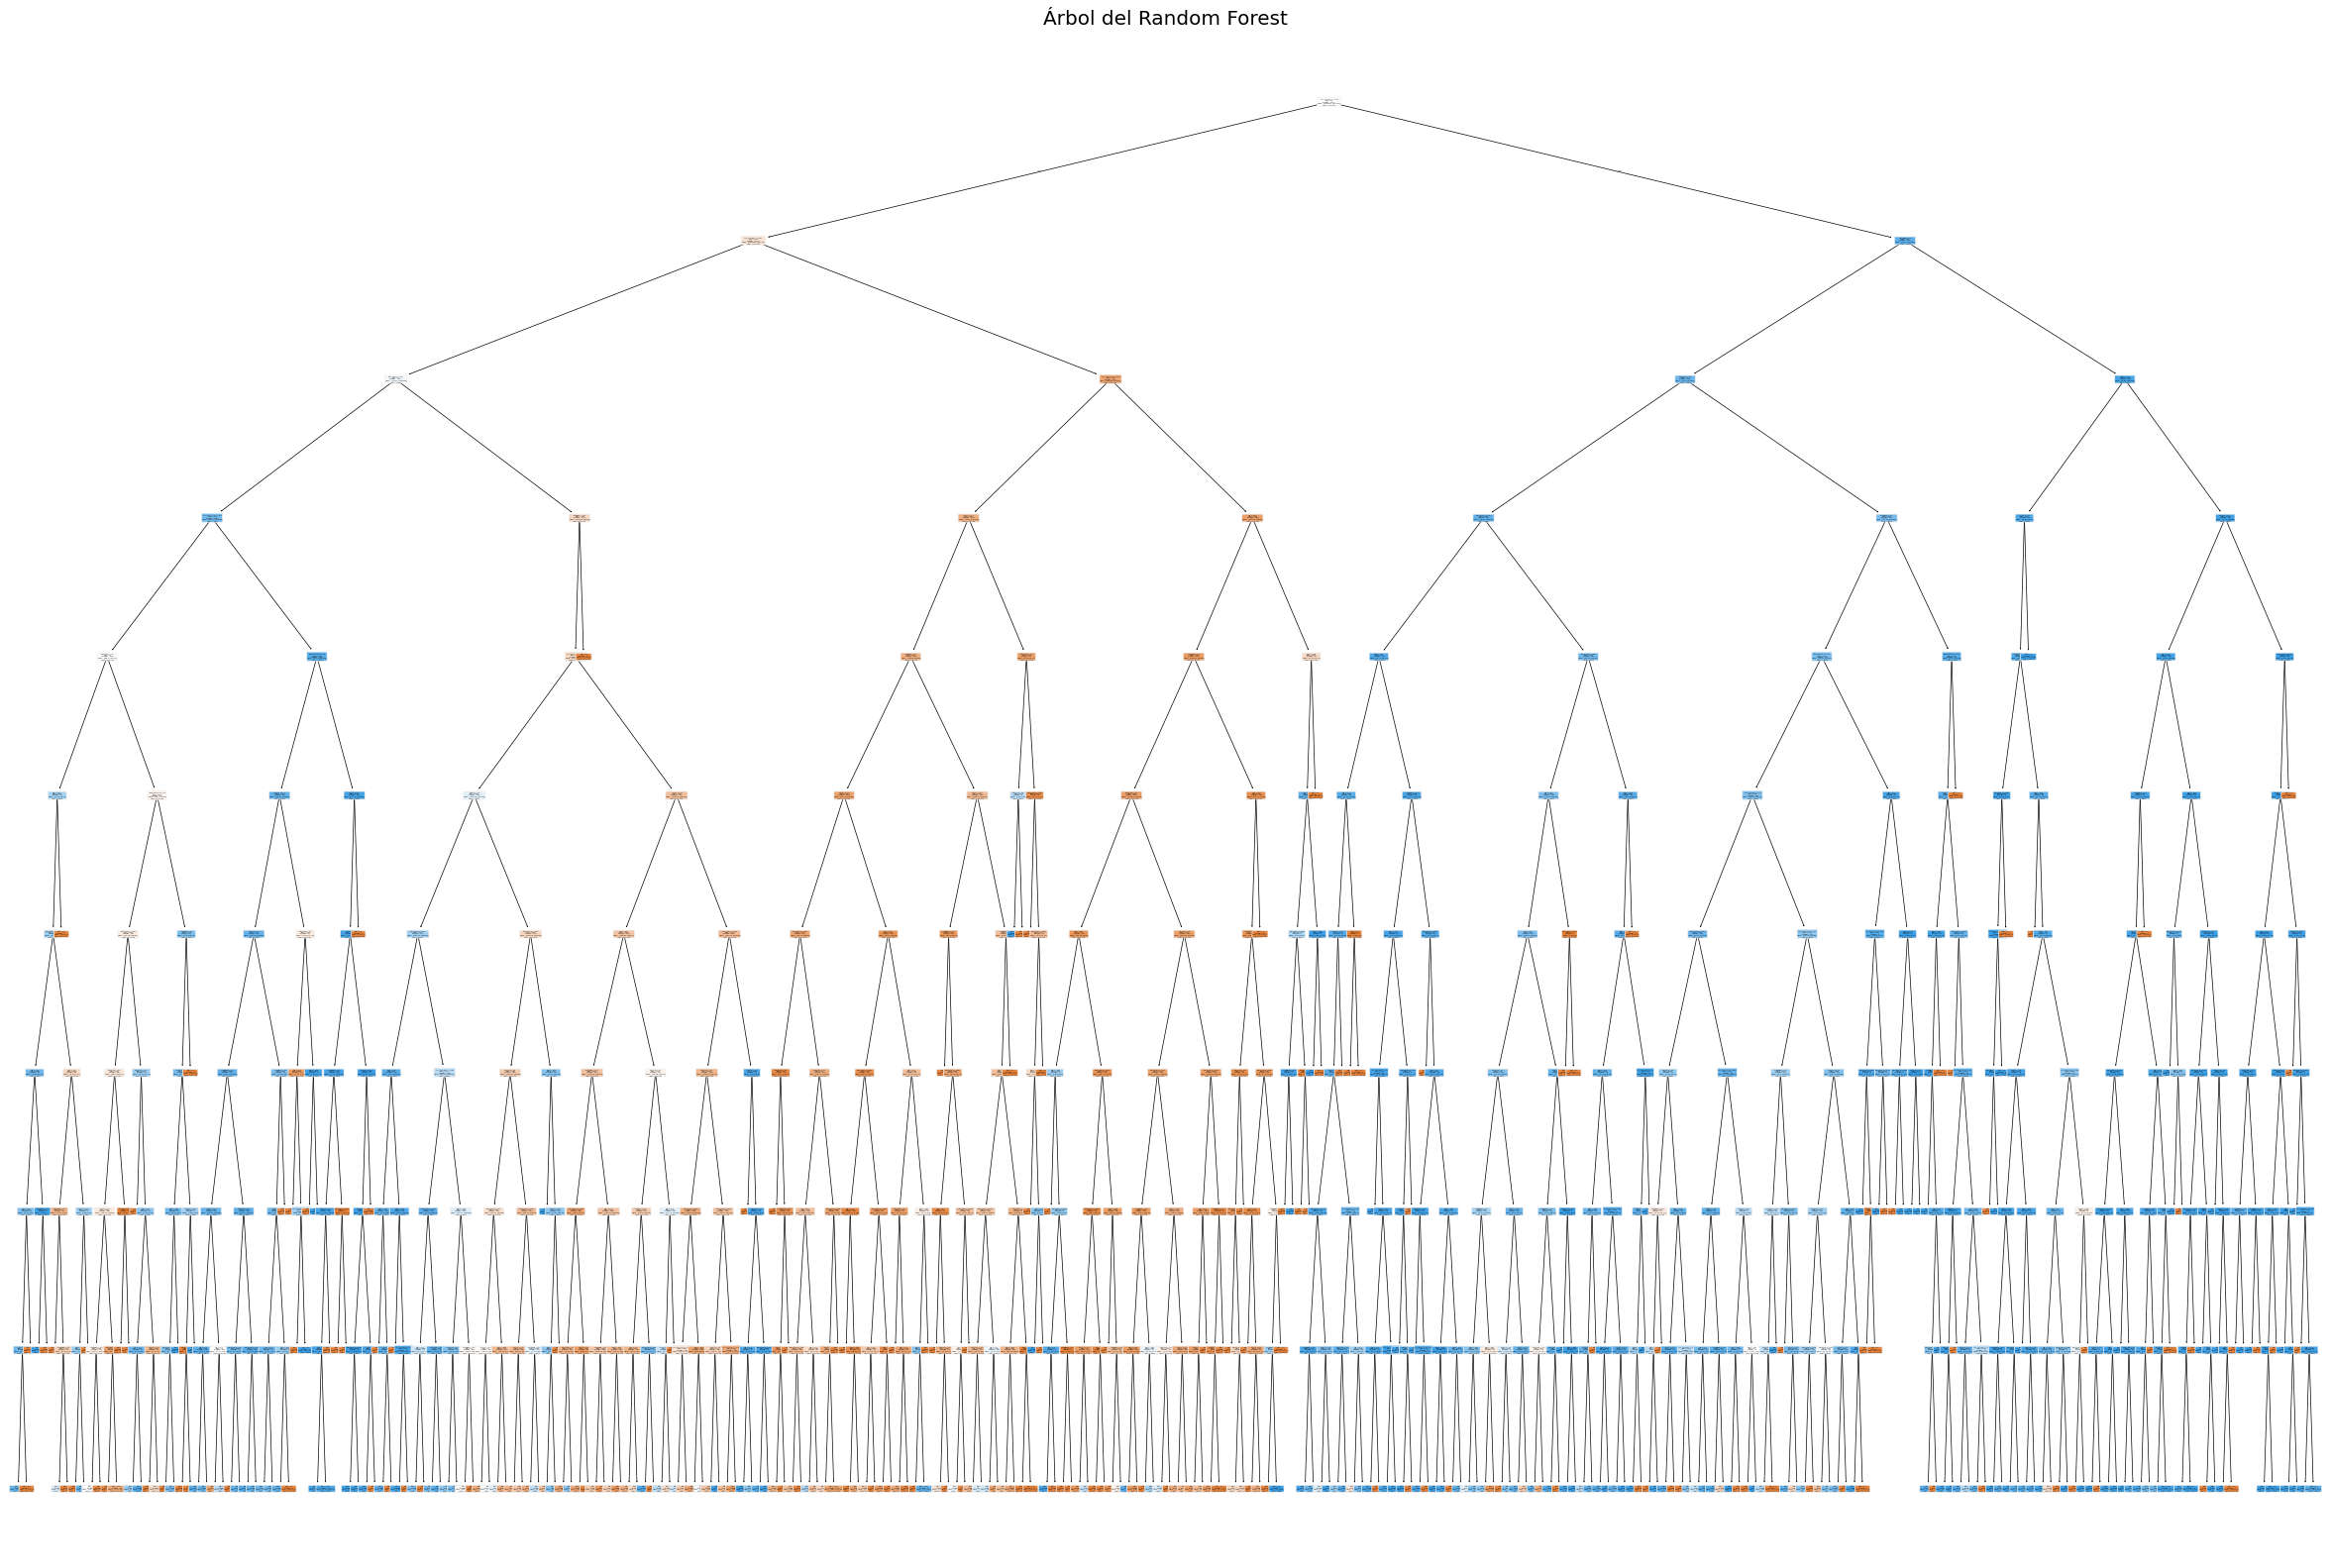

In [50]:
plt.figure(figsize=(30, 20))
plot_tree(
    crf.estimators_[0],
    feature_names=features,
    class_names=target,
    filled=True,
    impurity=True,
    rounded=True
)
plt.title('Árbol del Random Forest')
plt.show()

#### SVM

SVM busca el "hiperplano" que maximice el margen entre las clases (clientes que dicen "sí" vs "no"). Es extremadamente eficaz en espacios de alta dimensionalidad (muchas variables).
El kernel RBF se eligió porque transforma el problema de clasificación en algo mucho más flexible, permitiendo que el SVM no solo busque "cortes rectos" en los datos, sino que aprenda la forma real en la que se distribuyen los clientes interesados en el crédito.

In [51]:
svm = make_pipeline(
    StandardScaler(), 
    SVC(
        kernel='rbf',             
        class_weight='balanced',  
        C=1.0,                    
        gamma='scale',            
        probability=True,         
        random_state=42
    )
)

In [52]:
svm.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


## 6. Análisis de resultados

#### LogisticRegression

In [53]:
# Umbral para la decisión
prob_th = 0.7
prob_df=pd.DataFrame(clf.predict_proba(X_test[:10]),columns=['Prob of NO','Prob of YES'])
prob_df['Decision']=(prob_df['Prob of YES']>prob_th).apply(int)
prob_df

,Prob of NO,Prob of YES,Decision
0,0.314711,0.685289,0
1,0.225100,0.774900,1
2,0.660265,0.339735,0
3,0.585912,0.414088,0
4,0.664390,0.335610,0
5,0.371937,0.628063,0
6,0.595984,0.404016,0
7,0.764986,0.235014,0
8,0.248155,0.751845,1
9,0.753144,0.246856,0


In [54]:
print('Score: {}'.format(clf.score(X_test, y_test)))
print("Precisión en elconjunto de datos de entrenamiento: {:.3f}".format(clf.score(X_train, y_train)))
print("Precisión en el conjunto de datos de evaluación: {:.3f}".format(clf.score(X_test, y_test)))

Score: 0.755099562894609
Precisión en elconjunto de datos de entrenamiento: 0.751
Precisión en el conjunto de datos de evaluación: 0.755


#### RandomForestClassifier

In [55]:
print('Score: {}'.format(crf.score(X_test, y_test)))
print("Precisión en conjunto de datos de entrenamiento: {:.3f}".format(crf.score(X_train, y_train)))
print("Precisión en el conjunto de datos de evaluación: {:.3f}".format(crf.score(X_test, y_test)))

Score: 0.8575764934434191
Precisión en conjunto de datos de entrenamiento: 0.869
Precisión en el conjunto de datos de evaluación: 0.858


#### SVM

In [56]:
print('Score: {}'.format(svm.score(X_test, y_test)))
print("Precisión en conjunto de datos de entrenamiento: {:.3f}".format(svm.score(X_train, y_train)))
print("Precisión en el conjunto de datos de evaluación: {:.3f}".format(svm.score(X_test, y_test)))

Score: 0.843249150072851
Precisión en conjunto de datos de entrenamiento: 0.847
Precisión en el conjunto de datos de evaluación: 0.843


## 7. Realización de predicciones

#### LogisticRegression

In [57]:
print(confusion_matrix(y_test, (clf.predict_proba(X_test)[:, 1] >= 0.6).astype(int))) # si la probabilidad es mayor a a 0.6 devuelve True o False.

[[6085 1223]
 [ 372  556]]


In [58]:
print(classification_report(y_test, (clf.predict_proba(X_test)[:, 1] >= 0.6).astype(int)))

              precision    recall  f1-score   support

           0       0.94      0.83      0.88      7308
           1       0.31      0.60      0.41       928

    accuracy                           0.81      8236
   macro avg       0.63      0.72      0.65      8236
weighted avg       0.87      0.81      0.83      8236



El modelo muestra un rendimiento aceptable, con una precisión global del 81 %, lo que indica que la mayoría de las predicciones son correctas. La clase mayoritaria, correspondiente a clientes a los que no se concede el crédito, se predice con alta precisión y buen recall, reflejando que el modelo identifica de forma fiable los casos de riesgo.

En cambio, la clase minoritaria, clientes a los que sí se concede el crédito, presenta menor precisión y F1-score. Esto se debe al desbalance de clases, ya que la mayoría de los datos corresponden a créditos rechazados, lo que dificulta que el modelo aprenda a detectar correctamente los casos positivos.

En conjunto, el modelo adopta un comportamiento prudente y conservador, priorizando reducir el riesgo de conceder créditos a clientes no solventes.

In [59]:
print('Score: {}'.format(clf.score(X_test, y_test)))

Score: 0.755099562894609


In [60]:
probas = clf.predict_proba(credit_test)[:, 1]
predicciones_clf = (probas >= 0.7).astype(int)
predicciones_clf

array([0, 0, 0, ..., 0, 0, 0], shape=(4119,))

In [61]:
pd.Series(predicciones_clf).value_counts()

0    3701
1     418
Name: count, dtype: int64

In [73]:
conteo = pd.Series(predicciones_clf).value_counts()
total = conteo.sum()

porc_no = conteo[0] / total * 100
porc_si = conteo[1] / total * 100

print(f"El {porc_no:.2f}% de los clientes NO recibió el crédito.")
print(f"El {porc_si:.2f}% de los clientes SÍ recibió el crédito.")

El 89.85% de los clientes NO recibió el crédito.
El 10.15% de los clientes SÍ recibió el crédito.


#### RandomForestClassifier

In [62]:
print(confusion_matrix(y_test, crf.predict(X_test)))

[[6520  788]
 [ 385  543]]


In [63]:
print(classification_report(y_test, crf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.94      0.89      0.92      7308
           1       0.41      0.59      0.48       928

    accuracy                           0.86      8236
   macro avg       0.68      0.74      0.70      8236
weighted avg       0.88      0.86      0.87      8236



El modelo muestra un buen rendimiento general, con una accuracy del 86 %, lo que indica que predice correctamente la mayoría de los casos. La clase mayoritaria, clientes a los que no se concede el crédito, mantiene una alta precisión y recall (0.94 y 0.89), lo que demuestra que el modelo identifica de forma fiable los casos de riesgo.

La clase minoritaria, clientes a los que sí se concede el crédito, presenta mejoras respecto a resultados anteriores: ahora el recall es 0.59 y la precisión 0.41, lo que refleja que el modelo ha aprendido mejor a identificar estos casos, aunque sigue siendo más difícil debido al desbalance de clases.

En conjunto, el modelo adopta un comportamiento prudente y conservador, priorizando minimizar el riesgo financiero.

In [64]:
probas = crf.predict_proba(credit_test)[:, 1]
predicciones_crf = (probas >= 0.7).astype(int)
predicciones_crf

array([0, 0, 0, ..., 0, 0, 0], shape=(4119,))

In [65]:
pd.Series(predicciones_crf).value_counts()

0    3690
1     429
Name: count, dtype: int64

In [74]:
conteo = pd.Series(predicciones_crf).value_counts()
total = conteo.sum()

porc_no = conteo[0] / total * 100
porc_si = conteo[1] / total * 100

print(f"El {porc_no:.2f}% de los clientes NO recibió el crédito.")
print(f"El {porc_si:.2f}% de los clientes SÍ recibió el crédito.")

El 89.58% de los clientes NO recibió el crédito.
El 10.42% de los clientes SÍ recibió el crédito.


#### SVM

In [66]:
print(confusion_matrix(y_test, svm.predict(X_test)))

[[6391  917]
 [ 374  554]]


In [67]:
print(classification_report(y_test, svm.predict(X_test)))

              precision    recall  f1-score   support

           0       0.94      0.87      0.91      7308
           1       0.38      0.60      0.46       928

    accuracy                           0.84      8236
   macro avg       0.66      0.74      0.69      8236
weighted avg       0.88      0.84      0.86      8236



El modelo alcanza una exactitud global del 84 %, mostrando que predice correctamente la mayoría de los casos. La clase mayoritaria, clientes a los que no se concede el crédito, mantiene una alta precisión (0.94) y buen recall (0.87), lo que indica que el modelo identifica de manera fiable los casos de riesgo.

La clase minoritaria, clientes a los que sí se concede el crédito, sigue siendo más difícil de predecir debido al desbalance de clases; aunque el recall es 0.60, la precisión es más baja (0.38), reflejando que el modelo aún comete errores al identificar clientes que podrían recibir crédito.

En conjunto, el modelo adopta un enfoque prudente y conservador, priorizando minimizar riesgos financieros.

In [68]:
probas = svm.predict_proba(credit_test)[:, 1]
predicciones_svm = (probas >= 0.4).astype(int)
predicciones_svm

array([0, 0, 0, ..., 0, 0, 0], shape=(4119,))

In [69]:
pd.Series(predicciones_svm).value_counts()

0    3711
1     408
Name: count, dtype: int64

In [75]:
conteo = pd.Series(predicciones_svm).value_counts()
total = conteo.sum()

porc_no = conteo[0] / total * 100
porc_si = conteo[1] / total * 100

print(f"El {porc_no:.2f}% de los clientes NO recibió el crédito.")
print(f"El {porc_si:.2f}% de los clientes SÍ recibió el crédito.")

El 90.09% de los clientes NO recibió el crédito.
El 9.91% de los clientes SÍ recibió el crédito.


## 8. Visualización

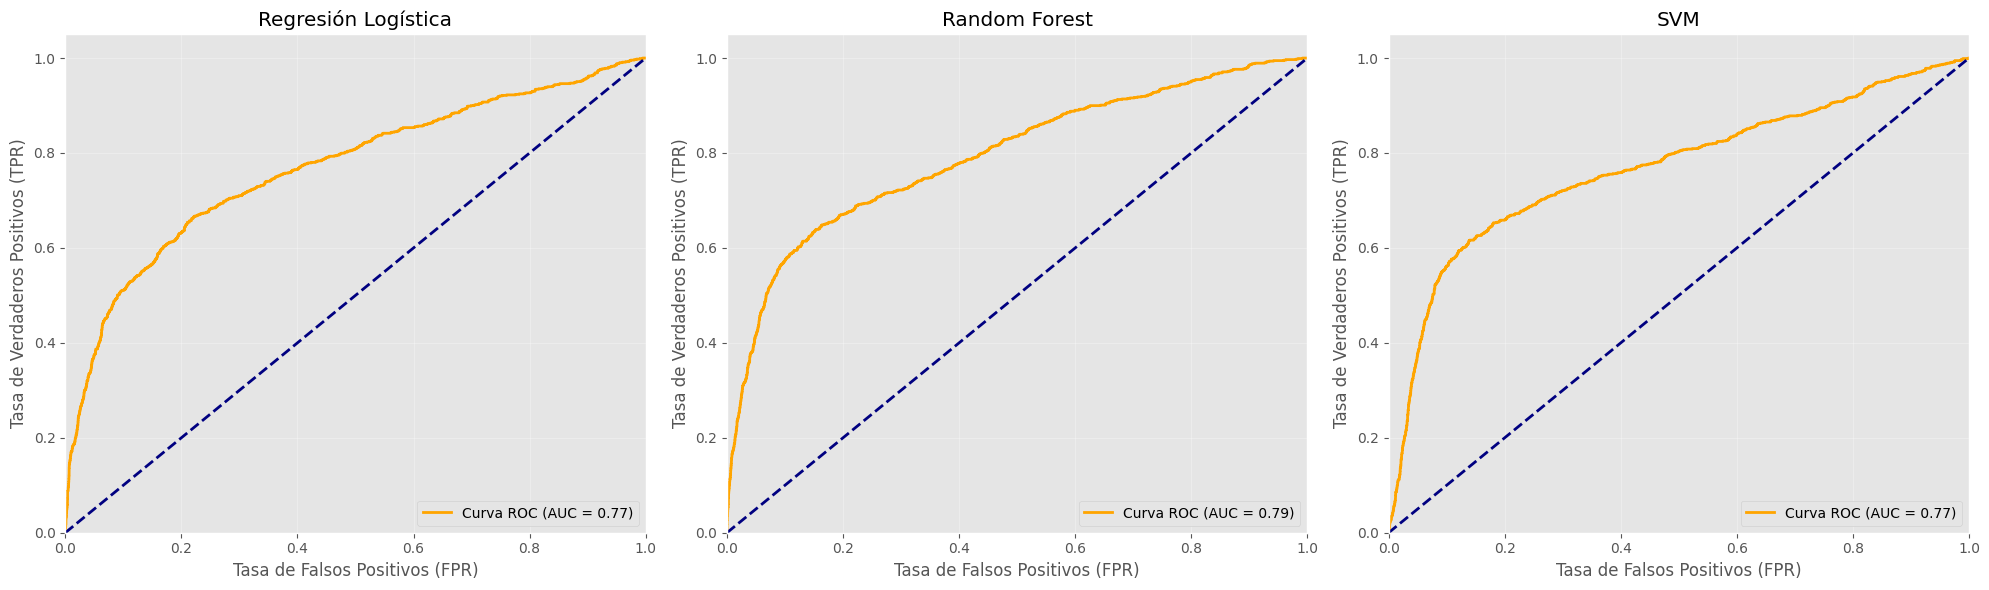

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

models = [
    ('Regresión Logística', clf),
    ('Random Forest', crf),
    ('SVM', svm)
]

for ax, (nombre, modelo) in zip(axes, models):
    
    y_probs = modelo.predict_proba(X_test)[:, 1]
    
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, color='orange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Línea base aleatoria
    
    # Decoración del gráfico
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    ax.set_title(f'{nombre}')
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

El Random Forest no solo tiene mejor equilibrio F1-Score (como vimos en las tablas), sino que domina matemáticamente el espacio de probabilidades (como vemos en esta curva ROC).

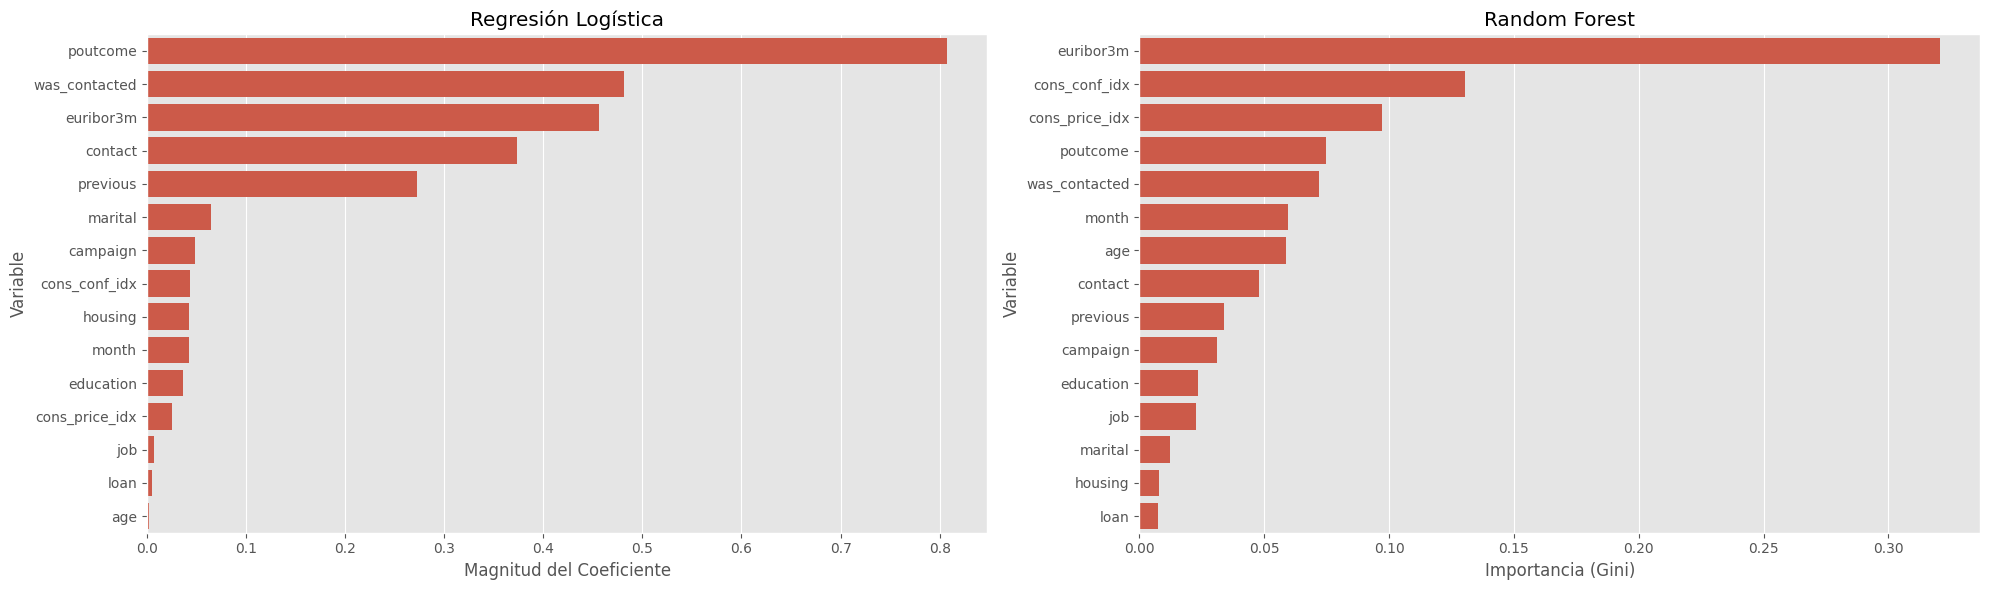

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

models = [
    ('Regresión Logística', clf),
    ('Random Forest', crf)
]

feature_names = X.columns

for ax, (nombre, modelo) in zip(axes, models):

    # Random Forest
    if hasattr(modelo, 'feature_importances_'):
        importances = modelo.feature_importances_
        xlabel = 'Importancia (Gini)'

    # Regresión Logística y SVM lineal
    elif hasattr(modelo, 'coef_'):
        importances = np.abs(modelo.coef_[0])
        xlabel = 'Magnitud del Coeficiente'

    else:
        raise ValueError(f'El modelo {nombre} no permite calcular importancias')

    feature_imp_df = (
        pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        })
        .sort_values(by='Importance', ascending=False)
    )

    sns.barplot(
        x='Importance',
        y='Feature',
        data=feature_imp_df,
        ax=ax
    )

    ax.set_title(nombre)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Variable')

plt.tight_layout()
plt.show()

Regresión Logística (Enfoque en el Pasado): Este modelo depende casi exclusivamente de la variable poutcome (resultado de la campaña de marketing anterior). Asume una relación lineal fuerte: "Si el cliente aceptó antes, aceptará ahora". Esto puede ser riesgoso si las condiciones del mercado cambian.

Random Forest (Enfoque en el Entorno): Prioriza variables económicas externas como euribor3m (tasas de interés), cons_conf_idx (confianza del consumidor) y cons_price_idx (IPC). Este modelo sugiere que la decisión del cliente depende más de la situación económica actual que de su historial pasado

SVM: El modelo SVM no permite calcular importancias 

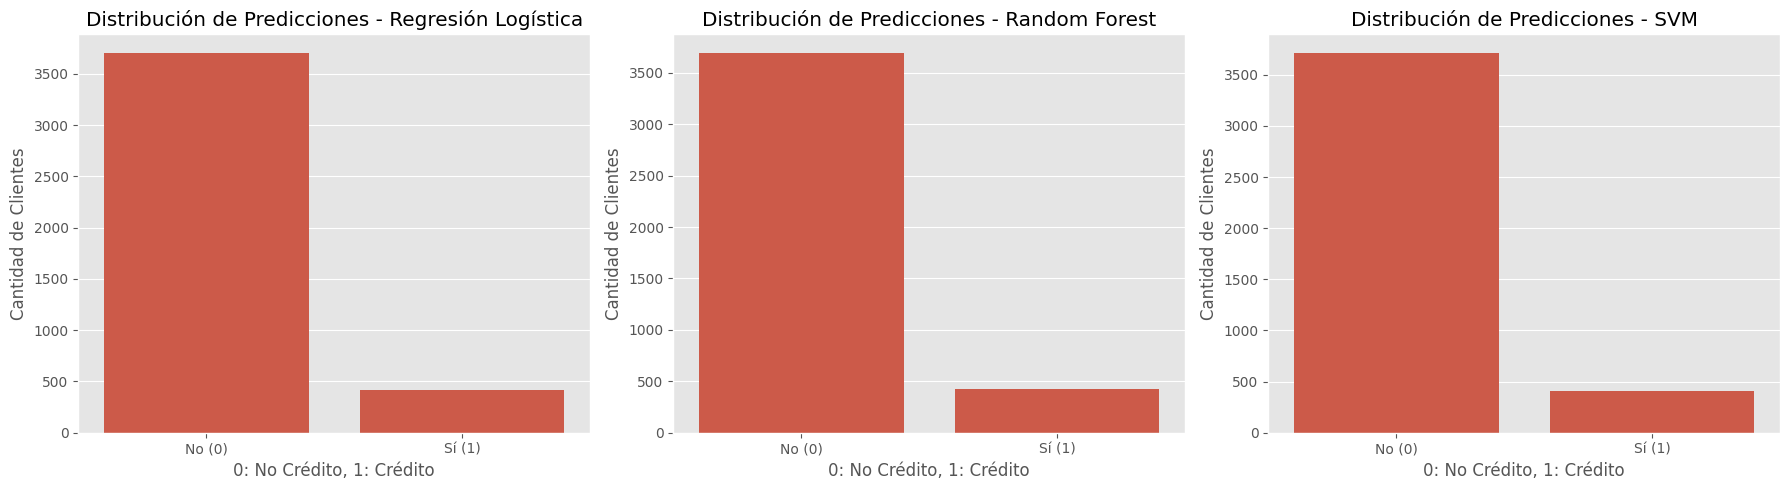

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

predicciones = [
    ('Regresión Logística', predicciones_clf),
    ('Random Forest', predicciones_crf),
    ('SVM', predicciones_svm)
]

for ax, (nombre, preds) in zip(axes, predicciones):

    sns.countplot(x=preds, ax=ax)

    ax.set_title(f'Distribución de Predicciones - {nombre}')
    ax.set_xlabel('0: No Crédito, 1: Crédito')
    ax.set_ylabel('Cantidad de Clientes')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No (0)', 'Sí (1)'])

plt.tight_layout()
plt.show()


Ante la duda, el modelo dice NO. Para que la barra naranja suba, el modelo tiene que estar muy seguro. No se la juega.

## 9. Conclusiones

## Conclusiones Individuales

### 1. Logistic Regression 
* **Conclusión:** Es el modelo más **agresivo**, ideal si no toleras perder ni un solo caso, pero costoso de operar.
* **Por qué:** Tiene el **Recall más alto (0.62)**. Encuentra más positivos que nadie (575).
* **El precio:** Su precisión es muy baja (0.31). Genera una cantidad masiva de ruido (1279 falsas alarmas). Es como una red de pesca gigante: atrapa el pez que quieres, pero también mucha basura.

### 2. SVM (Support Vector Machine) 
* **Conclusión:** Muy potente detectando (Recall 0.60), casi igualando a la Regresión Logística, pero con mejor precisión.
* **Desventaja:** Computacionalmente es pesado y lento. Aunque sus resultados son buenos, el Random Forest logra un mejor equilibrio general en menos tiempo de entrenamiento.

### 3. Random Forest - *(Campeón)*
* **Conclusión:** Es el modelo **más robusto y equilibrado** de la prueba.
* **Por qué:**
    * Tiene el mejor **F1-Score (0.49)**.
    * Mantiene un Recall alto (0.59), muy cerca de los líderes agresivos.
    * Mantiene una Precisión aceptable (0.41), reduciendo las falsas alarmas significativamente comparado con Logistic Reg. o SVM.